# Performance: Branched & Ring Molecules (MiniDrugBank)

Benchmark parameterization for molecules with complex topology (rings, branches) where the NetworkX to OpenMM matcher switch in PR #430 matters most.

In [1]:
import signal
import time

import matplotlib.pyplot as plt
import numpy as np
import openmm
from openff.toolkit import ForceField as OFFForceField
from openff.toolkit import Molecule
from openmm.app import ForceField, NoCutoff
from rdkit import Chem

from openmmforcefields.generators import SMIRNOFFTemplateGenerator
from openmmforcefields.utils import get_data_filename

In [23]:
FF_FILE = "openff_no_water-3.0.0-alpha0.offxml"
TIMEOUT = 9999


class TimeoutError(Exception):
    pass


def _timeout_handler(signum, frame):
    raise TimeoutError("Timed out")


def time_interchange(mol, ff_file):
    ff = OFFForceField(ff_file)
    top = mol.to_topology()
    start = time.perf_counter()
    ff.create_openmm_system(top)
    return time.perf_counter() - start


def time_ommffs(mol, ff_file):
    generator = SMIRNOFFTemplateGenerator(molecules=[mol], forcefield=ff_file)
    openmm_ff = ForceField()
    openmm_ff.registerTemplateGenerator(generator.generator)
    omm_top = mol.to_topology().to_openmm()
    start = time.perf_counter()
    openmm_ff.createSystem(omm_top, nonbondedMethod=NoCutoff)
    return time.perf_counter() - start


def benchmark_with_timeout(func, mol, ff_file, timeout_s):
    old_handler = signal.signal(signal.SIGALRM, _timeout_handler)
    signal.alarm(timeout_s)
    try:
        result = func(mol, ff_file)
        signal.alarm(0)
        return result
    except TimeoutError:
        return None
    finally:
        signal.signal(signal.SIGALRM, old_handler)

## Load and Categorize MiniDrugBank Molecules

In [24]:
sdf_path = get_data_filename("minidrugbank/MiniDrugBank.sdf")
supplier = Chem.SDMolSupplier(sdf_path, removeHs=False)

mol_info = []
for idx, rdmol in enumerate(supplier):
    if rdmol is None:
        continue
    n_atoms = rdmol.GetNumAtoms()
    n_heavy = rdmol.GetNumHeavyAtoms()
    n_rings = rdmol.GetRingInfo().NumRings()
    smiles = Chem.MolToSmiles(rdmol)
    mol_info.append({"idx": idx, "n_atoms": n_atoms, "n_heavy": n_heavy, "n_rings": n_rings, "smiles": smiles})

print(f"Loaded {len(mol_info)} molecules from MiniDrugBank")
print(f"Heavy atom range: {min(m['n_heavy'] for m in mol_info)} - {max(m['n_heavy'] for m in mol_info)}")
print(f"Ring count range: {min(m['n_rings'] for m in mol_info)} - {max(m['n_rings'] for m in mol_info)}")

Loaded 371 molecules from MiniDrugBank
Heavy atom range: 4 - 94
Ring count range: 0 - 8


In [25]:
# Select ~20 representative molecules spanning size and complexity
import random
random.seed(42)

# Bin by (size_bucket, ring_bucket) and pick one from each
size_bins = [0, 15, 25, 35, 50, 100]
ring_bins = [0, 1, 3, 5, 10]

selected = []
for si in range(len(size_bins) - 1):
    for ri in range(len(ring_bins) - 1):
        candidates = [
            m for m in mol_info
            if size_bins[si] <= m["n_heavy"] < size_bins[si + 1]
            and ring_bins[ri] <= m["n_rings"] < ring_bins[ri + 1]
        ]
        if candidates:
            selected.append(random.choice(candidates))

print(f"Selected {len(selected)} representative molecules")
for m in sorted(selected, key=lambda x: x["n_heavy"]):
    print(f"  n_heavy={m['n_heavy']:3d}, n_rings={m['n_rings']:2d}, smiles={m['smiles'][:60]}")

Selected 17 representative molecules
  n_heavy= 10, n_rings= 0, smiles=[H]OC(=O)[C@@]([H])(O[H])C([H])([H])S(=O)(=O)O[H]
  n_heavy= 11, n_rings= 3, smiles=[H]C1([H])N(P(=S)(N2C([H])([H])C2([H])[H])N2C([H])([H])C2([H
  n_heavy= 13, n_rings= 1, smiles=[H]OS(=O)(=O)C([H])([H])C([H])([H])C([H])([H])N1C([H])([H])C
  n_heavy= 16, n_rings= 2, smiles=[H]Oc1c([H])c([H])c([H])c([H])c1-c1c([H])c([H])c([H])c([H])c
  n_heavy= 20, n_rings= 0, smiles=[H]C([H])([H])C([H])([H])C([H])([H])C([H])([H])C([H])([H])C(
  n_heavy= 21, n_rings= 3, smiles=[H]OC(=O)c1nc([C@@]2([H])N([H])C([H])([H])c3c([H])c([H])c([H
  n_heavy= 22, n_rings= 5, smiles=[H]OC(=O)C([H])([H])C([H])([H])[C@]12OO[C@](C([H])([H])[H])(
  n_heavy= 25, n_rings= 0, smiles=[H]/C(=C(/[H])C([H])([H])/C([H])=C(\[H])C([H])([H])C([H])([H
  n_heavy= 28, n_rings= 2, smiles=[H]OC(=O)C(O/N=C(\C(=O)N([H])[C@]1([H])C(=O)N(S(=O)(=O)[O-])
  n_heavy= 29, n_rings= 5, smiles=[H]c1c([H])c(OC(C(=O)N([H])[C@@]2([H])[C@@]3([H])C([H])([H])
  n_heavy= 31, n_rings= 

In [50]:
# Add synthetic fused ring systems
fused_rings = [
    ("benzene", "c1ccccc1"),
    ("naphthalene", "c1ccc2ccccc2c1"),
    ("anthracene", "c1ccc2cc3ccccc3cc2c1"),
    ("tetracene", "c1ccc2cc3cc4ccccc4cc3cc2c1"),
    ("cyclocyclohexane", "C1C6CC(CC1)[C@@H]2C[C@H](CCC2)C3C[C@H](CCC3)C4C[C@H](CCC4)C5C[C@H](CCC5)C7C[C@@H]6CCC7"),
    ("beeeeeeeeenzene", "C1=CC=C2C(=C1)C=C3C(=C2)C=C4C(=C3)C=C5C(=C4)C=C6C(=C5)C=C7C(=C6)C=C8C(=C7)C=C9C(=C8)C=CC=C9"),
    ("b8nzene_with_megacycle", "C1=CC=C2C(=C1)C%11=C3C(=C2)C=C4C(=C3)C=C5C(=C4)C=C6C(=C5)C=C7C(=C6)C=C8C(=C7)C(=C9C(=C8)C=CC=C9)CCCCCCC(C(CCCCCC(CCC(CCCCCCC(CC(CCC(CC(CC(CCCCC%10C(C)C(CC)C(C(C)C%10CCCC(CCCCCC(CC%11CC)CCC)C(CC)C)C)C)C)C)CC(C)C)C)CC(C)C)CC(C)C)CC(C)C)C"),
    ("b8nzene_with_crosslinks", "C1=CC%16=C2C(=C1)C%17=C3C(=C2)C=C4C(=C3)C=C7C5=C4C(C(C)CC(C)CCC(CC(C)CCCCC9CC(CCC(CCCCCC8C%11CC6=C%10C(=CC(=C5)C6=C7CC(C8)C)C9=C%13C%12=C%10CC(CCCC%11)CC%12=C%14C(=C%13)C=CC=C%14)CC(C)C)CC(C)C)CC(C)C)C(CCCCC%15C(C)C(CC)C(C(C)C%15CCCC(C%16CCCCC(CC%17CC)CCC)C(CC)C)C)C"),
    ("branchy_madness", "C" + ("C(CNCC)(CNCC)"*100) + "C"),
    
]

synthetic = []
for name, smi in fused_rings:
    print(name)
    mol = Molecule.from_smiles(smi, allow_undefined_stereo=True)
    n_heavy = sum(1 for a in mol.atoms if a.atomic_number != 1)
    n_rings = len(Chem.GetSSSR(mol.to_rdkit()))
    #n_rings = mol.to_rdkit().GetRingInfo().NumRings()
    synthetic.append({"name": name, "smiles": smi, "n_heavy": n_heavy, "n_rings": n_rings})
    print(f"  {name}: {n_heavy} heavy atoms, {n_rings} rings")

benzene
  benzene: 6 heavy atoms, 1 rings
naphthalene
  naphthalene: 10 heavy atoms, 2 rings
anthracene
  anthracene: 14 heavy atoms, 3 rings
tetracene
  tetracene: 18 heavy atoms, 4 rings
cyclocyclohexane
  cyclocyclohexane: 36 heavy atoms, 7 rings
beeeeeeeeenzene
  beeeeeeeeenzene: 38 heavy atoms, 9 rings
b8nzene_with_megacycle
  b8nzene_with_megacycle: 128 heavy atoms, 11 rings
b8nzene_with_crosslinks
  b8nzene_with_crosslinks: 129 heavy atoms, 17 rings
branchy_madness
  branchy_madness: 902 heavy atoms, 0 rings


## Benchmark

In [51]:
results = []

# Benchmark MiniDrugBank selections
for m in selected:
    break
    try:
        mol = Molecule.from_smiles(m["smiles"], allow_undefined_stereo=True)
        #mol.generate_conformers(n_conformers=1)
    except Exception as e:
        print(f"  Skipping {m['smiles'][:40]}... ({e})")
        continue

    print(f"Benchmarking {m['smiles'][:40]}... (heavy={m['n_heavy']}, rings={m['n_rings']})")
    ic_t = benchmark_with_timeout(time_interchange, mol, FF_FILE, TIMEOUT)
    of_t = benchmark_with_timeout(time_ommffs, mol, FF_FILE, TIMEOUT)

    ic_str = f"{ic_t:.3f}s" if ic_t else "TIMEOUT"
    of_str = f"{of_t:.3f}s" if of_t else "TIMEOUT"
    print(f"  IC={ic_str}, OMMFFS={of_str}")

    results.append({
        "label": m["smiles"][:30],
        "n_heavy": m["n_heavy"],
        "n_rings": m["n_rings"],
        "interchange": ic_t,
        "ommffs": of_t,
        "source": "MiniDrugBank",
    })

# Benchmark synthetic fused rings
for m in synthetic:
    mol = Molecule.from_smiles(m["smiles"], allow_undefined_stereo=True)
    #mol.generate_conformers(n_conformers=1)
    print(f"Benchmarking {m['name']}...")
    ic_t = benchmark_with_timeout(time_interchange, mol, FF_FILE, TIMEOUT)
    of_t = benchmark_with_timeout(time_ommffs, mol, FF_FILE, TIMEOUT)
    ic_str = f"{ic_t:.3f}s" if ic_t else "TIMEOUT"
    of_str = f"{of_t:.3f}s" if of_t else "TIMEOUT"
    print(f"  IC={ic_str}, OMMFFS={of_str}")
    results.append({
        "label": m["name"],
        "n_heavy": m["n_heavy"],
        "n_rings": m["n_rings"],
        "interchange": ic_t,
        "ommffs": of_t,
        "source": "synthetic",
    })

print(f"\nBenchmarked {len(results)} molecules total")

Benchmarking benzene...
  IC=1.106s, OMMFFS=1.217s
Benchmarking naphthalene...
  IC=0.958s, OMMFFS=0.806s
Benchmarking anthracene...
  IC=1.094s, OMMFFS=0.875s
Benchmarking tetracene...
  IC=1.050s, OMMFFS=0.869s
Benchmarking cyclocyclohexane...
  IC=1.152s, OMMFFS=1.059s
Benchmarking beeeeeeeeenzene...
  IC=1.244s, OMMFFS=0.923s
Benchmarking b8nzene_with_megacycle...


[15:57:03] WARNING: Omitted undefined stereo

[15:57:05] WARNING: Omitted undefined stereo



  IC=1.424s, OMMFFS=1.273s
Benchmarking b8nzene_with_crosslinks...


[15:57:06] WARNING: Omitted undefined stereo

[15:57:08] WARNING: Omitted undefined stereo



  IC=1.275s, OMMFFS=1.504s
Benchmarking branchy_madness...
  IC=5.079s, OMMFFS=8.561s

Benchmarked 9 molecules total


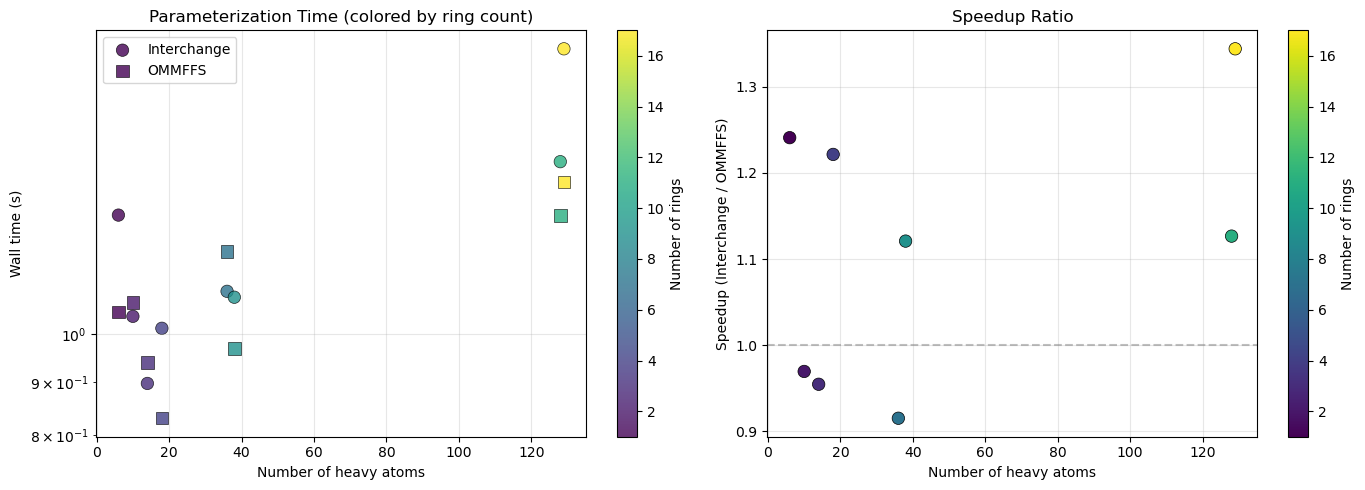

In [47]:
# Filter valid results
valid = [r for r in results if r["interchange"] is not None and r["ommffs"] is not None]

if valid:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    n_heavy = [r["n_heavy"] for r in valid]
    n_rings = [r["n_rings"] for r in valid]
    ic_times = [r["interchange"] for r in valid]
    of_times = [r["ommffs"] for r in valid]
    speedups = [ic / of for ic, of in zip(ic_times, of_times)]

    # Scatter: time vs n_atoms colored by n_rings
    scatter1 = ax1.scatter(n_heavy, ic_times, c=n_rings, cmap="viridis", marker="o",
                           s=80, edgecolors="black", linewidths=0.5, label="Interchange", alpha=0.8)
    ax1.scatter(n_heavy, of_times, c=n_rings, cmap="viridis", marker="s",
                s=80, edgecolors="black", linewidths=0.5, label="OMMFFS", alpha=0.8)
    ax1.set_xlabel("Number of heavy atoms")
    ax1.set_ylabel("Wall time (s)")
    ax1.set_title("Parameterization Time (colored by ring count)")
    ax1.legend()
    ax1.set_yscale("log")
    ax1.grid(True, alpha=0.3)
    plt.colorbar(scatter1, ax=ax1, label="Number of rings")

    # Speedup ratio vs n_atoms
    scatter2 = ax2.scatter(n_heavy, speedups, c=n_rings, cmap="viridis",
                           s=80, edgecolors="black", linewidths=0.5)
    ax2.axhline(y=1, color="gray", linestyle="--", alpha=0.5)
    ax2.set_xlabel("Number of heavy atoms")
    ax2.set_ylabel("Speedup (Interchange / OMMFFS)")
    ax2.set_title("Speedup Ratio")
    ax2.grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=ax2, label="Number of rings")

    plt.tight_layout()
    plt.savefig("branched_ring_performance.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No valid data to plot")

In [48]:
# Summary table
print(f"{'Label':<32} {'Heavy':>6} {'Rings':>6} {'IC (s)':>10} {'OMMFFS (s)':>12} {'Speedup':>10}")
print("-" * 78)
for r in sorted(valid, key=lambda x: x["n_heavy"]):
    sp = r["interchange"] / r["ommffs"]
    print(f"{r['label']:<32} {r['n_heavy']:6d} {r['n_rings']:6d} {r['interchange']:10.4f} {r['ommffs']:12.4f} {sp:10.1f}x")

if valid:
    avg_speedup = np.mean([r["interchange"] / r["ommffs"] for r in valid])
    print(f"\nAverage speedup: {avg_speedup:.1f}x")

Label                             Heavy  Rings     IC (s)   OMMFFS (s)    Speedup
------------------------------------------------------------------------------
benzene                               6      1     1.3037       1.0506        1.2x
naphthalene                          10      2     1.0409       1.0735        1.0x
anthracene                           14      3     0.8967       0.9391        1.0x
tetracene                            18      4     1.0137       0.8299        1.2x
cyclocyclohexane                     36      7     1.1005       1.2023        0.9x
beeeeeeeeenzene                      38      9     1.0861       0.9690        1.1x
b8nzene_with_megacycle              128     11     1.4682       1.3031        1.1x
b8nzene_with_crosslinks             129     17     1.8869       1.4040        1.3x

Average speedup: 1.1x


In [49]:
# Analysis: which molecule types benefit most
if valid:
    high_ring = [r for r in valid if r["n_rings"] >= 3]
    low_ring = [r for r in valid if r["n_rings"] < 3]

    if high_ring:
        avg_high = np.mean([r["interchange"] / r["ommffs"] for r in high_ring])
        print(f"Average speedup for molecules with >= 3 rings: {avg_high:.1f}x")
    if low_ring:
        avg_low = np.mean([r["interchange"] / r["ommffs"] for r in low_ring])
        print(f"Average speedup for molecules with < 3 rings:  {avg_low:.1f}x")

    large = [r for r in valid if r["n_heavy"] >= 25]
    small = [r for r in valid if r["n_heavy"] < 25]
    if large:
        avg_large = np.mean([r["interchange"] / r["ommffs"] for r in large])
        print(f"Average speedup for molecules with >= 25 heavy atoms: {avg_large:.1f}x")
    if small:
        avg_small = np.mean([r["interchange"] / r["ommffs"] for r in small])
        print(f"Average speedup for molecules with < 25 heavy atoms:  {avg_small:.1f}x")

Average speedup for molecules with >= 3 rings: 1.1x
Average speedup for molecules with < 3 rings:  1.1x
Average speedup for molecules with >= 25 heavy atoms: 1.1x
Average speedup for molecules with < 25 heavy atoms:  1.1x
